# EDA — Base de candidatos (Hackathon Enter)

Análise exploratória da planilha oficial `Hackaton_Enter_Base_Candidatos.xlsx`:
catálogo de features e opções, dependências estruturais e estatísticas,
distribuições, associações com o resultado e conclusões para o produto.

**Fonte:** `../data/Hackaton_Enter_Base_Candidatos.xlsx` (60.000 processos, duas abas).
**Fora deste notebook:** `Entregas Hackathon UFMG.xlsx` (log de submissão) e os PDFs dos Casos 01/02
(não estão na base; números 2024 vs processos 2025).

Como rodar (venv na raiz do repo):

```bash
python3 -m venv .venv
.venv/bin/pip install -r notebooks/requirements.txt
.venv/bin/jupyter notebook notebooks/eda_base_candidatos.ipynb
```

No Cursor, escolha o kernel **Python (.venv)**.


## 1. Setup e carga

Padronizamos nomes de colunas em snake_case. A aba de subsídios tem uma linha de
legenda (`1 = fornecido`, `0 = não`) e um typo no header (`Número do processos`).
O join é 1:1 pelo número do processo.


In [4]:
from pathlib import Path
import re
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from scipy.stats import chi2_contingency
from sklearn.metrics import normalized_mutual_info_score

warnings.filterwarnings("ignore", category=FutureWarning)

pd.set_option("display.max_columns", 60)
pd.set_option("display.max_rows", 80)
pd.set_option("display.width", 140)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 4.5)
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["figure.dpi"] = 110

DATA_PATH = Path("..") / "data" / "Hackaton_Enter_Base_Candidatos.xlsx"
if not DATA_PATH.exists():
    DATA_PATH = Path("data") / "Hackaton_Enter_Base_Candidatos.xlsx"
EXAMPLE_CASES = [
    "0801234-56.2024.8.10.0001",
    "0654321-09.2024.8.04.0001",
]
CRITICAL_DOCS = ["has_contrato", "has_extrato", "has_comprovante"]
DOC_COLS = [
    "has_contrato",
    "has_extrato",
    "has_comprovante",
    "has_dossie",
    "has_demonstrativo",
    "has_laudo",
]
DOC_LABELS = {
    "has_contrato": "Contrato",
    "has_extrato": "Extrato",
    "has_comprovante": "Comprovante de crédito",
    "has_dossie": "Dossiê",
    "has_demonstrativo": "Demonstrativo",
    "has_laudo": "Laudo referenciado",
}

# IBGE 2024 resident population estimates (approx., millions) — only to contrast
# the uniform UF sample against a real population prior.
IBGE_POP_M = {
    "AC": 0.91, "AL": 3.24, "AM": 4.29, "AP": 0.80, "BA": 14.87,
    "CE": 9.24, "DF": 3.09, "ES": 4.02, "GO": 7.35, "MA": 7.08,
    "MG": 21.41, "MS": 2.90, "MT": 3.84, "PA": 8.54, "PB": 4.15,
    "PE": 9.54, "PI": 3.29, "PR": 11.83, "RJ": 17.46, "RN": 3.53,
    "RO": 1.75, "RR": 0.72, "RS": 11.23, "SC": 8.06, "SE": 2.29,
    "SP": 46.02, "TO": 1.58,
}


In [5]:
def cramers_v(x: pd.Series, y: pd.Series) -> float:
    table = pd.crosstab(x, y)
    if table.size == 0 or table.shape[0] < 2 or table.shape[1] < 2:
        return np.nan
    chi2, _, _, _ = chi2_contingency(table, correction=False)
    n = table.to_numpy().sum()
    r, k = table.shape
    return float(np.sqrt(chi2 / (n * (min(r, k) - 1))))


def cramers_v_matrix(frame: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    matrix = pd.DataFrame(index=columns, columns=columns, dtype=float)
    for left in columns:
        for right in columns:
            if left == right:
                matrix.loc[left, right] = 1.0
            elif left > right:
                continue
            else:
                value = cramers_v(frame[left], frame[right])
                matrix.loc[left, right] = value
                matrix.loc[right, left] = value
    return matrix


def cnj_year(process_number: str) -> int | None:
    match = re.search(r"\.(\d{4})\.", str(process_number))
    return int(match.group(1)) if match else None


def show(frame: pd.DataFrame, title: str | None = None) -> None:
    if title:
        print(title)
    display(frame)


In [6]:
assert DATA_PATH.exists(), f"Missing dataset: {DATA_PATH.resolve()}"

results_raw = pd.read_excel(DATA_PATH, sheet_name="Resultados dos processos")
subsidies_raw = pd.read_excel(
    DATA_PATH,
    sheet_name="Subsídios disponibilizados",
    skiprows=1,
)

print("Aba 1 shape:", results_raw.shape)
print("Aba 1 columns:", list(results_raw.columns))
print("Aba 2 shape:", subsidies_raw.shape)
print("Aba 2 columns:", list(subsidies_raw.columns))


Aba 1 shape: (60000, 8)
Aba 1 columns: ['Número do processo', 'UF', 'Assunto', 'Sub-assunto', 'Resultado macro', 'Resultado micro', 'Valor da causa', 'Valor da condenação/indenização']
Aba 2 shape: (60000, 7)
Aba 2 columns: ['Número do processos', 'Contrato', 'Extrato', 'Comprovante de crédito', 'Dossiê', 'Demonstrativo de evolução da dívida', 'Laudo referenciado']


In [7]:
results = results_raw.rename(
    columns={
        "Número do processo": "process_number",
        "UF": "uf",
        "Assunto": "assunto",
        "Sub-assunto": "sub_assunto",
        "Resultado macro": "resultado_macro",
        "Resultado micro": "resultado_micro",
        "Valor da causa": "valor_causa",
        "Valor da condenação/indenização": "valor_condenacao",
    }
)

subsidies = subsidies_raw.rename(
    columns={
        "Número do processos": "process_number",
        "Contrato": "has_contrato",
        "Extrato": "has_extrato",
        "Comprovante de crédito": "has_comprovante",
        "Dossiê": "has_dossie",
        "Demonstrativo de evolução da dívida": "has_demonstrativo",
        "Laudo referenciado": "has_laudo",
    }
)

for col in DOC_COLS:
    subsidies[col] = subsidies[col].astype(int)

df = results.merge(subsidies, on="process_number", how="inner", validate="1:1")

n_results = len(results)
n_subsidies = len(subsidies)
n_joined = len(df)
only_results = set(results["process_number"]) - set(subsidies["process_number"])
only_subsidies = set(subsidies["process_number"]) - set(results["process_number"])

print(f"rows results={n_results:,}  subsidies={n_subsidies:,}  inner join={n_joined:,}")
print(f"unique keys results={results['process_number'].nunique():,}  subsidies={subsidies['process_number'].nunique():,}")
print(f"keys only in results={len(only_results)}  only in subsidies={len(only_subsidies)}")

assert n_results == 60_000
assert n_subsidies == 60_000
assert n_joined == 60_000
assert results["process_number"].is_unique
assert subsidies["process_number"].is_unique
assert len(only_results) == 0 and len(only_subsidies) == 0

df["is_exito"] = df["resultado_macro"].eq("Êxito")
df["is_acordo"] = df["resultado_micro"].eq("Acordo")
df["n_docs"] = df[DOC_COLS].sum(axis=1)
df["n_criticos"] = df[CRITICAL_DOCS].sum(axis=1)
df["vd_over_vc"] = np.where(
    df["valor_causa"] > 0,
    df["valor_condenacao"] / df["valor_causa"],
    np.nan,
)
df["cnj_year"] = df["process_number"].map(cnj_year)

print("Join 1:1 confirmado. Preview:")
display(df.head())


rows results=60,000  subsidies=60,000  inner join=60,000
unique keys results=60,000  subsidies=60,000
keys only in results=0  only in subsidies=0
Join 1:1 confirmado. Preview:


,process_number,uf,assunto,sub_assunto,resultado_macro,resultado_micro,valor_causa,valor_condenacao,has_contrato,has_extrato,has_comprovante,has_dossie,has_demonstrativo,has_laudo,is_exito,is_acordo,n_docs,n_criticos,vd_over_vc,cnj_year
0,1764352-89.2025.8.06.1818,CE,Não reconhece operação,Genérico,Não Êxito,Parcial procedência,"13,534.0000","7,714.3800",0,0,0,1,1,1,False,False,3,0,0.5700,2025
1,5638325-36.2025.8.17.4124,PE,Não reconhece operação,Golpe,Não Êxito,Parcial procedência,"7,883.6300","3,784.1424",1,1,0,1,1,1,False,False,5,2,0.4800,2025
2,1037491-89.2025.8.18.1658,PI,Não reconhece operação,Golpe,Não Êxito,Parcial procedência,"8,561.9700","6,507.0972",0,1,1,1,1,0,False,False,4,2,0.7600,2025
3,9547931-23.2025.8.04.4188,AM,Não reconhece operação,Golpe,Êxito,Improcedência,"5,693.1300",0.0000,1,1,1,1,1,0,True,False,5,3,0.0000,2025
4,9999446-69.2025.8.04.4264,AM,Não reconhece operação,Golpe,Êxito,Improcedência,"8,515.6700",0.0000,0,1,0,1,1,1,True,False,4,1,0.0000,2025


## 2. Dicionário de features e opções

Para cada coluna: tipo, cardinalidade, nulos, se é constante, e as opções
(categóricas) ou o resumo numérico (contínuas). Esta é a resposta direta a
“quais features existem e quais valores cada uma pode assumir”.


In [8]:
def feature_catalog(frame: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for col in frame.columns:
        series = frame[col]
        n_unique = int(series.nunique(dropna=False))
        n_null = int(series.isna().sum())
        is_numeric = pd.api.types.is_numeric_dtype(series)
        is_constant = n_unique == 1
        if is_numeric and n_unique > 12:
            options = (
                f"min={series.min():,.4f} · p25={series.quantile(0.25):,.4f} · "
                f"median={series.median():,.4f} · p75={series.quantile(0.75):,.4f} · "
                f"max={series.max():,.4f}"
            )
            kind = "numeric"
        else:
            counts = series.astype(str).value_counts(dropna=False)
            parts = [f"{idx} ({cnt:,})" for idx, cnt in counts.items()]
            options = " · ".join(parts[:20])
            if len(parts) > 20:
                options += f" · … +{len(parts) - 20} valores"
            kind = "constant" if is_constant else ("binary" if n_unique <= 2 else "categorical")
        rows.append(
            {
                "feature": col,
                "dtype": str(series.dtype),
                "kind": kind,
                "n_unique": n_unique,
                "n_null": n_null,
                "pct_null": n_null / len(frame),
                "is_constant": is_constant,
                "options_or_range": options,
            }
        )
    return pd.DataFrame(rows)

catalog = feature_catalog(df)
show(catalog, "Catálogo de features (tabela completa)")


Catálogo de features (tabela completa)


,feature,dtype,kind,n_unique,n_null,pct_null,is_constant,options_or_range
0,process_number,str,categorical,60000,0,0.0000,False,1764352-89.2025.8.06.1818 (1) · 5638325-36.202...
1,uf,str,categorical,26,0,0.0000,False,"CE (2,308) · PE (2,308) · PI (2,308) · AM (2,3..."
2,assunto,str,constant,1,0,0.0000,True,"Não reconhece operação (60,000)"
3,sub_assunto,str,binary,2,0,0.0000,False,"Golpe (41,628) · Genérico (18,372)"
4,resultado_macro,str,binary,2,0,0.0000,False,"Êxito (41,733) · Não Êxito (18,267)"
5,resultado_micro,str,categorical,5,0,0.0000,False,"Improcedência (27,935) · Extinção (13,798) · P..."
6,valor_causa,float64,numeric,58939,0,0.0000,False,"min=1,000.0000 · p25=11,535.5825 · median=14,9..."
7,valor_condenacao,float64,numeric,18263,0,0.0000,False,min=0.0000 · p25=0.0000 · median=0.0000 · p75=...
8,has_contrato,int64,binary,2,0,0.0000,False,"1 (42,983) · 0 (17,017)"
9,has_extrato,int64,binary,2,0,0.0000,False,"1 (48,895) · 0 (11,105)"


In [9]:
print("Valores únicos — resultado_micro:")
show(df["resultado_micro"].value_counts().rename("n").to_frame().assign(pct=lambda x: x["n"] / x["n"].sum()))

print("Valores únicos — resultado_macro:")
show(df["resultado_macro"].value_counts().rename("n").to_frame().assign(pct=lambda x: x["n"] / x["n"].sum()))

print("Valores únicos — sub_assunto:")
show(df["sub_assunto"].value_counts().rename("n").to_frame().assign(pct=lambda x: x["n"] / x["n"].sum()))

print("Valores únicos — assunto:")
show(df["assunto"].value_counts().rename("n").to_frame().assign(pct=lambda x: x["n"] / x["n"].sum()))

print("UFs (n = 26 ou 27?):")
uf_counts = (
    df["uf"].value_counts()
    .rename("n")
    .to_frame()
    .assign(pct=lambda x: x["n"] / x["n"].sum())
    .sort_index()
)
show(uf_counts)
print(f"n_ufs={df['uf'].nunique()}  min={uf_counts['n'].min()}  max={uf_counts['n'].max()}")


Valores únicos — resultado_micro:


,n,pct
resultado_micro,,
Improcedência,27935,0.4656
Extinção,13798,0.2300
Parcial procedência,12248,0.2041
Procedência,5739,0.0956
Acordo,280,0.0047


Valores únicos — resultado_macro:


,n,pct
resultado_macro,,
Êxito,41733,0.6956
Não Êxito,18267,0.3044


Valores únicos — sub_assunto:


...

Valores únicos — assunto:


,n,pct
assunto,,
Não reconhece operação,60000,1.0000


UFs (n = 26 ou 27?):


,n,pct
uf,,
AC,2308,0.0385
AL,2308,0.0385
AM,2308,0.0385
AP,2308,0.0385
BA,2308,0.0385
CE,2308,0.0385
DF,2308,0.0385
ES,2308,0.0385
GO,2308,0.0385


n_ufs=26  min=2307  max=2308


**Leitura do catálogo (a confirmar nos números acima):**

| Feature | Opções | Papel |
|---|---|---|
| `process_number` | 60k IDs CNJ-like, todos 2025 | chave, sem sinal preditivo |
| `uf` | 26 UFs (RR ausente), 2.307–2.308 cada | risco geográfico; amostra **balanceada**, não populacional |
| `assunto` | só `Não reconhece operação` | constante — sem informação |
| `sub_assunto` | `Golpe` / `Genérico` | tese do autor |
| `resultado_macro` | `Êxito` / `Não Êxito` | alvo de defesa (banco ganhou / pagou) |
| `resultado_micro` | 5 classes, Acordo ~0,47% | detalhe do desfecho; Acordo ⊂ Não Êxito |
| `valor_causa` | contínuo ~1k–31k | ticket / âncora de banda |
| `valor_condenacao` | 0 no êxito; >0 no loss | caixa pago |
| 6 flags `has_*` | `{0, 1}` | presença do PDF, **não** qualidade |


## 3. Qualidade dos dados

Nulos, duplicatas, lixo binário nos floats, ano CNJ, overlap com os casos-exemplo
e o quão artificial é o balanceamento por UF.


In [10]:
quality = pd.DataFrame(
    {
        "n_rows": [len(df)],
        "n_duplicate_rows": [int(df.duplicated().sum())],
        "n_duplicate_keys": [int(df["process_number"].duplicated().sum())],
        "n_null_cells": [int(df.isna().sum().sum())],
        "n_cnj_year_2025": [int(df["cnj_year"].eq(2025).sum())],
        "n_other_years": [int((df["cnj_year"] != 2025).sum())],
        "n_example_overlap": [int(df["process_number"].isin(EXAMPLE_CASES).sum())],
    }
)
show(quality, "Checagens de qualidade")

print("Nulos por coluna:")
show(df.isna().sum().rename("n_null").to_frame())

dirty_causa = df["valor_causa"] != df["valor_causa"].round(2)
dirty_cond = df["valor_condenacao"] != df["valor_condenacao"].round(2)
print(f"valor_causa com mais de 2 casas: {int(dirty_causa.sum()):,}")
print(f"valor_condenacao com mais de 2 casas: {int(dirty_cond.sum()):,}")
print("Exemplos de lixo binário (valor_condenacao):")
show(
    df.loc[dirty_cond, ["process_number", "valor_causa", "valor_condenacao"]]
    .head(8)
)


Checagens de qualidade


,n_rows,n_duplicate_rows,n_duplicate_keys,n_null_cells,n_cnj_year_2025,n_other_years,n_example_overlap
0,60000,0,0,0,60000,0,0


Nulos por coluna:


,n_null
process_number,0
uf,0
assunto,0
sub_assunto,0
resultado_macro,0
resultado_micro,0
valor_causa,0
valor_condenacao,0
has_contrato,0
has_extrato,0


valor_causa com mais de 2 casas: 0
valor_condenacao com mais de 2 casas: 17,323
Exemplos de lixo binário (valor_condenacao):


,process_number,valor_causa,valor_condenacao
0,1764352-89.2025.8.06.1818,"13,534.0000","7,714.3800"
1,5638325-36.2025.8.17.4124,"7,883.6300","3,784.1424"
2,1037491-89.2025.8.18.1658,"8,561.9700","6,507.0972"
5,2412149-28.2025.8.24.1145,"16,961.0600","12,720.7950"
8,6064536-08.2025.8.05.2439,"16,021.5000","9,773.1150"
12,4060328-48.2025.8.03.5952,"18,988.7800","17,089.9020"
22,1996289-38.2025.8.13.1427,"22,052.7700","11,246.9127"
25,8242761-70.2025.8.25.4530,"19,419.3400","16,700.6324"


UF: amostra uniforme vs prior IBGE 2024 (pp = pontos percentuais)


,n,pct,expected_uniform,pop_m,pop_share,sample_minus_pop_pp,abs_dev_from_uniform
uf,,,,,,,
SP,2307,0.0384,"2,307.6923",46.0200,0.2168,-17.8309,0.6923
MG,2308,0.0385,"2,307.6923",21.4100,0.1008,-6.2376,0.3077
RJ,2307,0.0384,"2,307.6923",17.4600,0.0822,-4.3788,0.6923
BA,2308,0.0385,"2,307.6923",14.8700,0.0700,-3.1572,0.3077
PR,2308,0.0385,"2,307.6923",11.8300,0.0557,-1.7254,0.3077
RS,2307,0.0384,"2,307.6923",11.2300,0.0529,-1.4444,0.6923
PE,2308,0.0385,"2,307.6923",9.5400,0.0449,-0.6468,0.3077
CE,2308,0.0385,"2,307.6923",9.2400,0.0435,-0.5055,0.3077
PA,2308,0.0385,"2,307.6923",8.5400,0.0402,-0.1758,0.3077


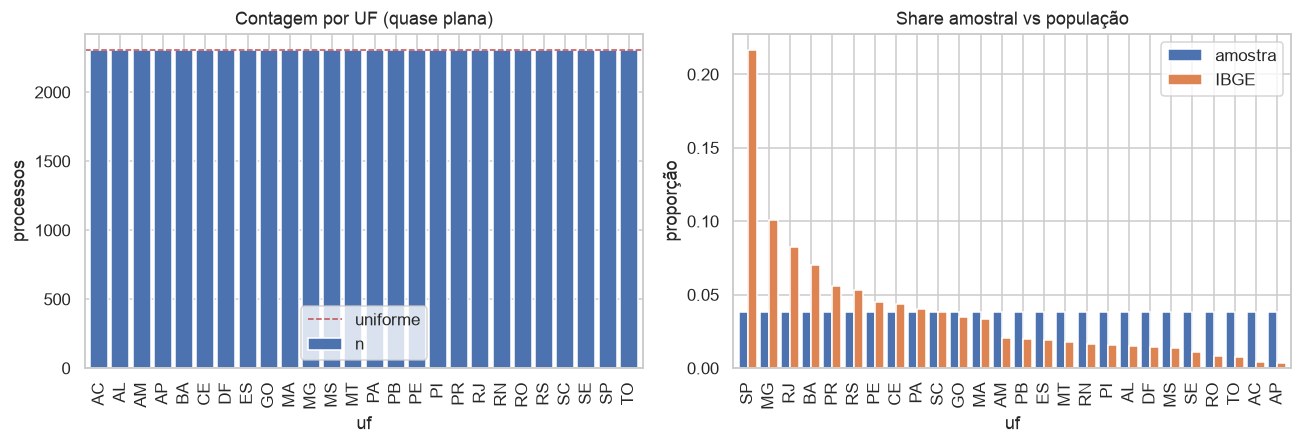

In [11]:
uf_quality = (
    uf_counts.assign(
        expected_uniform=60_000 / df["uf"].nunique(),
        pop_m=lambda x: x.index.map(IBGE_POP_M),
    )
)
uf_quality["pop_share"] = uf_quality["pop_m"] / uf_quality["pop_m"].sum()
uf_quality["sample_minus_pop_pp"] = (uf_quality["pct"] - uf_quality["pop_share"]) * 100
uf_quality["abs_dev_from_uniform"] = (uf_quality["n"] - uf_quality["expected_uniform"]).abs()
show(
    uf_quality.sort_values("sample_minus_pop_pp"),
    "UF: amostra uniforme vs prior IBGE 2024 (pp = pontos percentuais)",
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
uf_quality["n"].sort_index().plot(kind="bar", ax=axes[0], color="#4C72B0", width=0.85)
axes[0].axhline(uf_quality["expected_uniform"].iloc[0], color="#C44E52", ls="--", lw=1, label="uniforme")
axes[0].set_title("Contagem por UF (quase plana)")
axes[0].set_ylabel("processos")
axes[0].legend()

compare = uf_quality[["pct", "pop_share"]].rename(columns={"pct": "amostra", "pop_share": "IBGE"})
compare.sort_values("IBGE", ascending=False).plot(kind="bar", ax=axes[1], width=0.85)
axes[1].set_title("Share amostral vs população")
axes[1].set_ylabel("proporção")
plt.tight_layout()
plt.show()


## 4. Dependências estruturais (regras, não correlação)

Estas relações são determinísticas no arquivo: se valem em 60k/60k, são
**definição da tabela**, não achado estatístico.


In [12]:
macro_micro = pd.crosstab(df["resultado_macro"], df["resultado_micro"], margins=True)
show(macro_micro, "Crosstab macro × micro (deve particionar sem overlap)")

exito_micros = sorted(df.loc[df["is_exito"], "resultado_micro"].unique())
loss_micros = sorted(df.loc[~df["is_exito"], "resultado_micro"].unique())
print("Micro em Êxito:", exito_micros)
print("Micro em Não Êxito:", loss_micros)

cond_when_exito = df.loc[df["is_exito"], "valor_condenacao"]
cond_when_loss = df.loc[~df["is_exito"], "valor_condenacao"]
print(f"condenação no Êxito: min={cond_when_exito.min()} max={cond_when_exito.max()} n_zero={(cond_when_exito.eq(0)).sum():,}/{len(cond_when_exito):,}")
print(f"condenação no Não Êxito: min={cond_when_loss.min():,.4f} max={cond_when_loss.max():,.4f} n_zero={(cond_when_loss.eq(0)).sum():,}/{len(cond_when_loss):,}")

structural = pd.DataFrame(
    [
        {
            "rule": "assunto é constante",
            "holds": bool(df["assunto"].nunique() == 1),
            "detail": df["assunto"].iloc[0],
        },
        {
            "rule": "Êxito = Improcedência ∪ Extinção",
            "holds": set(exito_micros) == {"Improcedência", "Extinção"},
            "detail": str(exito_micros),
        },
        {
            "rule": "Não Êxito = Procedência ∪ Parcial ∪ Acordo",
            "holds": set(loss_micros) == {"Procedência", "Parcial procedência", "Acordo"},
            "detail": str(loss_micros),
        },
        {
            "rule": "condenação = 0 ⇔ Êxito",
            "holds": bool(cond_when_exito.eq(0).all() and (cond_when_loss > 0).all()),
            "detail": "zero no êxito; estritamente positivo no loss",
        },
        {
            "rule": "Acordo ⊂ Não Êxito",
            "holds": bool(df.loc[df["is_acordo"], "is_exito"].eq(False).all()),
            "detail": f"n_acordo={int(df['is_acordo'].sum()):,}",
        },
        {
            "rule": "join 1:1 entre abas",
            "holds": True,
            "detail": "validate='1:1' + 60k/60k",
        },
    ]
)
show(structural, "Regras estruturais")


Crosstab macro × micro (deve particionar sem overlap)


resultado_micro,Acordo,Extinção,Improcedência,Parcial procedência,Procedência,All
resultado_macro,,,,,,
Não Êxito,280,0,0,12248,5739,18267
Êxito,0,13798,27935,0,0,41733
All,280,13798,27935,12248,5739,60000


Micro em Êxito: ['Extinção', 'Improcedência']
Micro em Não Êxito: ['Acordo', 'Parcial procedência', 'Procedência']
condenação no Êxito: min=0.0 max=0.0 n_zero=41,733/41,733
condenação no Não Êxito: min=350.0000 max=28,414.6756 n_zero=0/18,267
Regras estruturais


,rule,holds,detail
0,assunto é constante,True,Não reconhece operação
1,Êxito = Improcedência ∪ Extinção,True,"['Extinção', 'Improcedência']"
2,Não Êxito = Procedência ∪ Parcial ∪ Acordo,True,"['Acordo', 'Parcial procedência', 'Procedência']"
3,condenação = 0 ⇔ Êxito,True,zero no êxito; estritamente positivo no loss
4,Acordo ⊂ Não Êxito,True,n_acordo=280
5,join 1:1 entre abas,True,validate='1:1' + 60k/60k


Implicação: `resultado_macro` e o indicador `valor_condenacao == 0` são
**funções** de `resultado_micro`. Usar os três juntos como features de um
modelo é vazamento. O alvo útil de “o banco pagou?” é o macro (ou o micro
colapsado). Acordo não é uma classe separada do ponto de vista de caixa —
o banco pagou.


## 5. Dependências entre flags de documento

Pergunta: os 6 PDFs “chegam juntos” (geração acoplada) ou a presença de um
é quase independente da dos outros?


Taxa de presença de cada subsídio


,presence_rate,n_present
Contrato,0.7164,42983
Extrato,0.8149,48895
Comprovante de crédito,0.6069,36414
Dossiê,0.6998,41986
Demonstrativo,0.7702,46215
Laudo referenciado,0.8010,48059


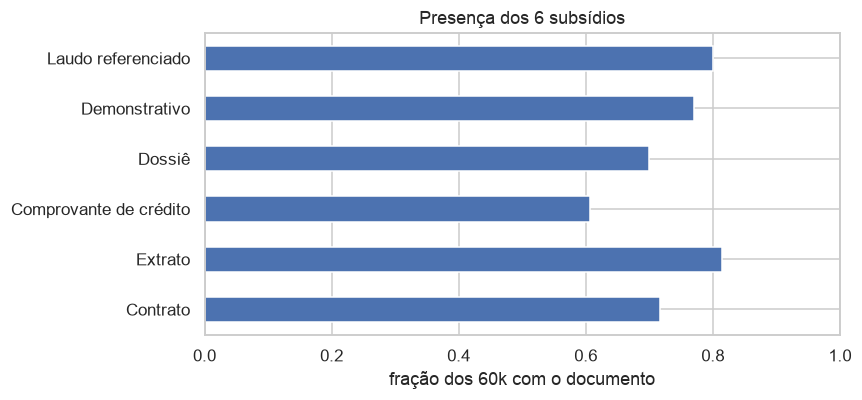

In [13]:
presence = (
    df[DOC_COLS]
    .mean()
    .rename("presence_rate")
    .to_frame()
)
presence.index = presence.index.map(DOC_LABELS)
presence["n_present"] = (presence["presence_rate"] * len(df)).round().astype(int)
show(presence, "Taxa de presença de cada subsídio")

fig, ax = plt.subplots(figsize=(8, 3.8))
presence["presence_rate"].plot(kind="barh", ax=ax, color="#4C72B0")
ax.set_xlim(0, 1)
ax.set_xlabel("fração dos 60k com o documento")
ax.set_title("Presença dos 6 subsídios")
plt.tight_layout()
plt.show()


Pearson entre flags 0/1


,Contrato,Extrato,Comprovante de crédito,Dossiê,Demonstrativo,Laudo referenciado
Contrato,1.0000,0.3183,0.1744,0.0031,0.0675,-0.0025
Extrato,0.3183,1.0000,0.1524,0.0022,0.0563,-0.0083
Comprovante de crédito,0.1744,0.1524,1.0000,0.0065,0.0295,-0.0028
Dossiê,0.0031,0.0022,0.0065,1.0000,0.0019,0.0030
Demonstrativo,0.0675,0.0563,0.0295,0.0019,1.0000,-0.0053
Laudo referenciado,-0.0025,-0.0083,-0.0028,0.0030,-0.0053,1.0000


Cramér's V entre flags


,Contrato,Extrato,Comprovante de crédito,Dossiê,Demonstrativo,Laudo referenciado
Contrato,1.0000,0.3183,0.1744,0.0031,0.0675,0.0025
Extrato,0.3183,1.0000,0.1524,0.0022,0.0563,0.0083
Comprovante de crédito,0.1744,0.1524,1.0000,0.0065,0.0295,0.0028
Dossiê,0.0031,0.0022,0.0065,1.0000,0.0019,0.0030
Demonstrativo,0.0675,0.0563,0.0295,0.0019,1.0000,0.0053
Laudo referenciado,0.0025,0.0083,0.0028,0.0030,0.0053,1.0000


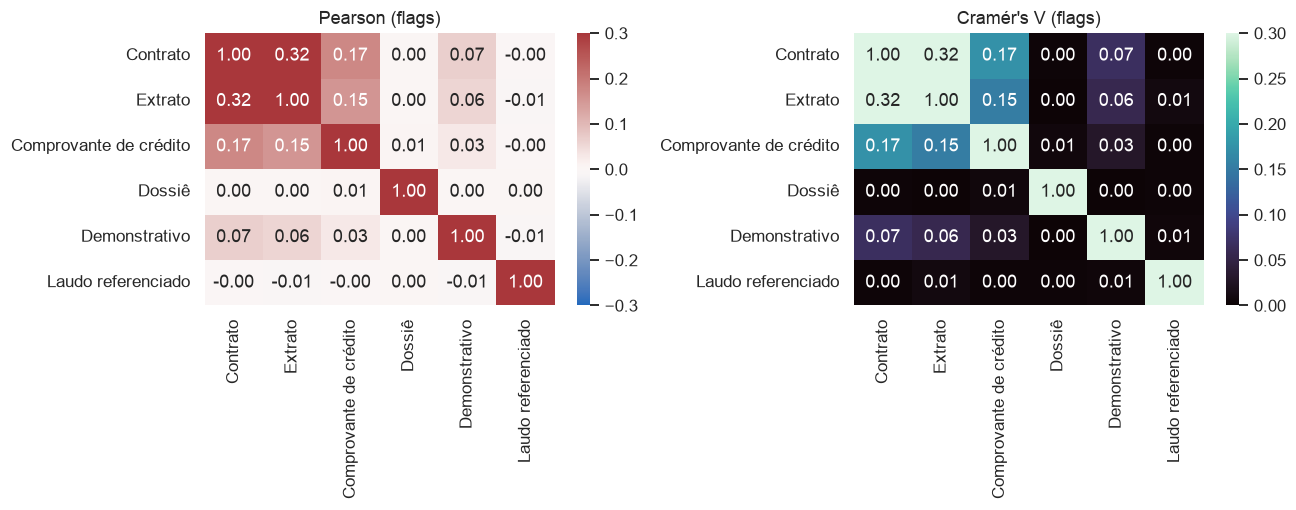

In [14]:
pearson_docs = df[DOC_COLS].corr()
pearson_docs.index = [DOC_LABELS[c] for c in DOC_COLS]
pearson_docs.columns = [DOC_LABELS[c] for c in DOC_COLS]
show(pearson_docs, "Pearson entre flags 0/1")

cramer_docs = cramers_v_matrix(df, DOC_COLS)
cramer_docs.index = [DOC_LABELS[c] for c in DOC_COLS]
cramer_docs.columns = [DOC_LABELS[c] for c in DOC_COLS]
show(cramer_docs, "Cramér's V entre flags")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
sns.heatmap(pearson_docs, annot=True, fmt=".2f", cmap="vlag", center=0, ax=axes[0], vmin=-0.3, vmax=0.3)
axes[0].set_title("Pearson (flags)")
sns.heatmap(cramer_docs, annot=True, fmt=".2f", cmap="mako", ax=axes[1], vmin=0, vmax=0.3)
axes[1].set_title("Cramér's V (flags)")
plt.tight_layout()
plt.show()


Maiores lifts P(B|A) / P(B)


,given,target,p_target_given,p_target_marginal,lift
0,Contrato,Extrato,0.8927,0.8149,1.0955
5,Extrato,Contrato,0.7848,0.7164,1.0955
1,Contrato,Comprovante de crédito,0.6605,0.6069,1.0883
10,Comprovante de crédito,Contrato,0.7796,0.7164,1.0883
6,Extrato,Comprovante de crédito,0.6424,0.6069,1.0585
11,Comprovante de crédito,Extrato,0.8626,0.8149,1.0585
3,Contrato,Demonstrativo,0.7881,0.7702,1.0232
20,Demonstrativo,Contrato,0.7330,0.7164,1.0232
21,Demonstrativo,Extrato,0.8269,0.8149,1.0146
8,Extrato,Demonstrativo,0.7815,0.7702,1.0146


Matriz de lift P(B=1 | A=1) / P(B=1)


target,Comprovante de crédito,Contrato,Demonstrativo,Dossiê,Extrato,Laudo referenciado
given,,,,,,
Comprovante de crédito,NaN,1.0883,1.0129,1.0034,1.0585,0.9989
Contrato,1.0883,NaN,1.0232,1.0013,1.0955,0.9992
Demonstrativo,1.0129,1.0232,NaN,1.0007,1.0146,0.9986
Dossiê,1.0034,1.0013,1.0007,NaN,1.0007,1.0010
Extrato,1.0585,1.0955,1.0146,1.0007,NaN,0.9980
Laudo referenciado,0.9989,0.9992,0.9986,1.0010,0.9980,NaN


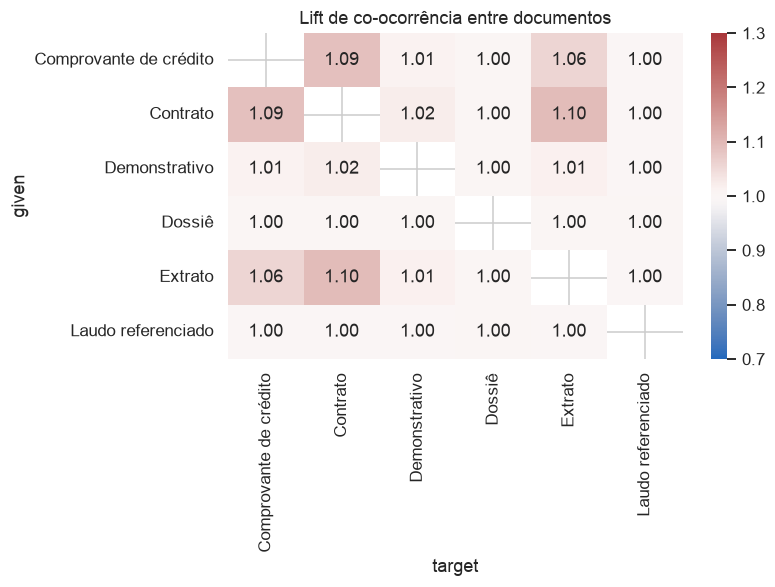

In [15]:
# P(flag B = 1 | flag A = 1) — if close to the marginal, flags are weakly dependent.
conditional_rows = []
for a in DOC_COLS:
    given = df[a].eq(1)
    for b in DOC_COLS:
        if a == b:
            continue
        conditional_rows.append(
            {
                "given": DOC_LABELS[a],
                "target": DOC_LABELS[b],
                "p_target_given": df.loc[given, b].mean(),
                "p_target_marginal": df[b].mean(),
                "lift": df.loc[given, b].mean() / df[b].mean(),
            }
        )
cond_table = pd.DataFrame(conditional_rows)
lift_matrix = cond_table.pivot(index="given", columns="target", values="lift")
show(cond_table.sort_values("lift", ascending=False).head(12), "Maiores lifts P(B|A) / P(B)")
show(lift_matrix, "Matriz de lift P(B=1 | A=1) / P(B=1)")

fig, ax = plt.subplots(figsize=(7.5, 5.5))
sns.heatmap(lift_matrix, annot=True, fmt=".2f", cmap="vlag", center=1, ax=ax, vmin=0.7, vmax=1.3)
ax.set_title("Lift de co-ocorrência entre documentos")
plt.tight_layout()
plt.show()


In [16]:
combo = (
    df.assign(
        contrato_extrato=df["has_contrato"].astype(str) + df["has_extrato"].astype(str),
        n_criticos=df["n_criticos"],
    )
)
print("Contrato × Extrato (contagem):")
show(pd.crosstab(df["has_contrato"], df["has_extrato"], margins=True))

print("P(extrato | contrato):")
show(df.groupby("has_contrato")["has_extrato"].mean().rename("p_extrato").to_frame())

print("Distribuição do nº de críticos (contrato+extrato+comprovante):")
show(
    df["n_criticos"]
    .value_counts()
    .sort_index()
    .rename("n")
    .to_frame()
    .assign(pct=lambda x: x["n"] / x["n"].sum())
)

print("Distribuição do nº total de docs (0–6):")
show(
    df["n_docs"]
    .value_counts()
    .sort_index()
    .rename("n")
    .to_frame()
    .assign(pct=lambda x: x["n"] / x["n"].sum())
)

print(
    "Leitura: Cramér's V baixo (~0.0x) ⇒ flags não são um bloco único. "
    "Ainda assim há combinações raras (0 docs) e o trio crítico não é independente do alvo — isso vem na §7."
)


Contrato × Extrato (contagem):


has_extrato,0,1,All
has_contrato,,,
0,6493,10524,17017
1,4612,38371,42983
All,11105,48895,60000


P(extrato | contrato):


,p_extrato
has_contrato,
0,0.6184
1,0.8927


Distribuição do nº de críticos (contrato+extrato+comprovante):


,n,pct
n_criticos,,
0,3880,0.0647
1,9946,0.1658
2,20176,0.3363
3,25998,0.4333


Distribuição do nº total de docs (0–6):


,n,pct
n_docs,,
0,57,0.0009
1,745,0.0124
2,3498,0.0583
3,8811,0.1469
4,15719,0.2620
5,19518,0.3253
6,11652,0.1942


Leitura: Cramér's V baixo (~0.0x) ⇒ flags não são um bloco único. Ainda assim há combinações raras (0 docs) e o trio crítico não é independente do alvo — isso vem na §7.


## 6. Univariada e o alvo

Como se espalham o desfecho, o ticket e a condenação. Acordo é classe rara:
não dá para treinar “acordo vs defesa” direto nos 60k.


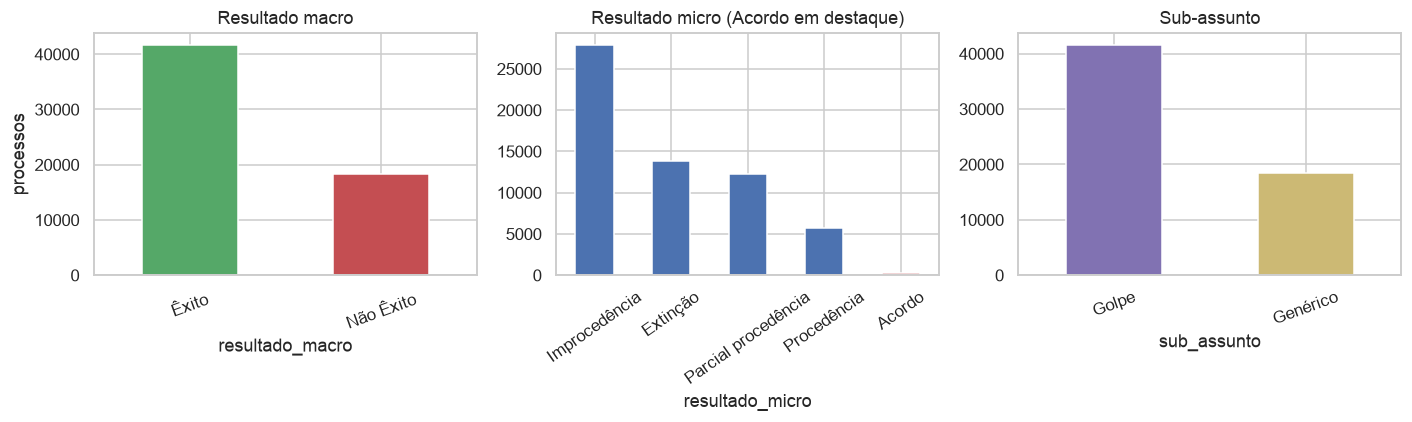

Acordo: 280 / 60,000 = 0.4667%
Êxito: 69.5550%  ·  Não Êxito (loss): 30.4450%


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

df["resultado_macro"].value_counts().plot(kind="bar", ax=axes[0], color=["#55A868", "#C44E52"])
axes[0].set_title("Resultado macro")
axes[0].tick_params(axis="x", rotation=20)
axes[0].set_ylabel("processos")

order_micro = (
    df["resultado_micro"].value_counts().index.tolist()
)
colors = ["#4C72B0" if x != "Acordo" else "#C44E52" for x in order_micro]
df["resultado_micro"].value_counts().loc[order_micro].plot(kind="bar", ax=axes[1], color=colors)
axes[1].set_title("Resultado micro (Acordo em destaque)")
axes[1].tick_params(axis="x", rotation=35)

df["sub_assunto"].value_counts().plot(kind="bar", ax=axes[2], color=["#8172B2", "#CCB974"])
axes[2].set_title("Sub-assunto")
axes[2].tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

n_acordo = int(df["is_acordo"].sum())
print(f"Acordo: {n_acordo:,} / {len(df):,} = {n_acordo / len(df):.4%}")
print(f"Êxito: {df['is_exito'].mean():.4%}  ·  Não Êxito (loss): {(~df['is_exito']).mean():.4%}")


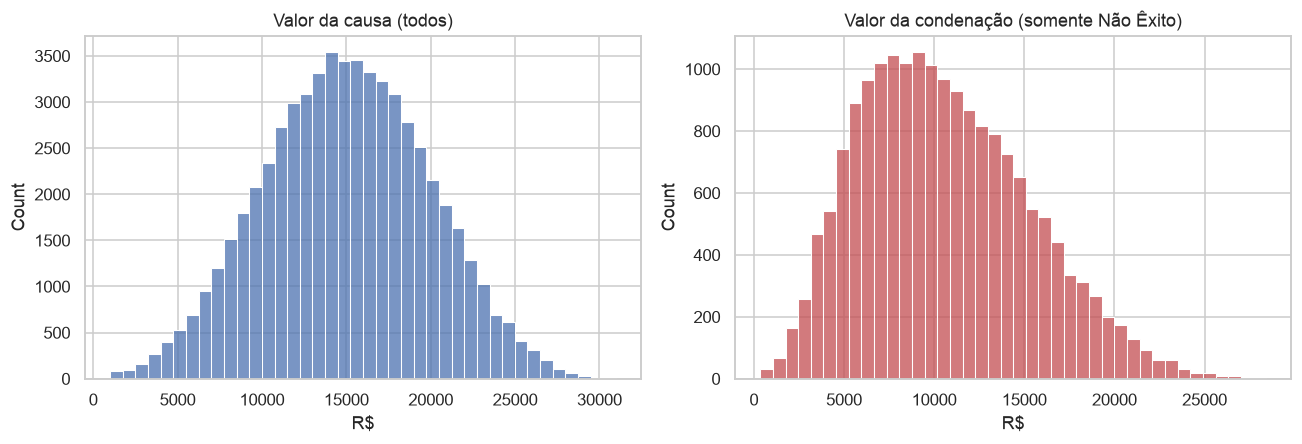

Resumo financeiro


,metric,value
0,n,"60,000"
1,valor_causa min / median / max,"1,000.00 / 14,992.93 / 30,979.20"
2,valor_causa mean,"14,982.19"
3,condenação total (Não Êxito),"R$ 192,982,862.07"
4,condenação mean / median no loss,"10,564.56 / 10,062.29"
5,n Êxito com condenação > 0,0


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
sns.histplot(df["valor_causa"], bins=40, ax=axes[0], color="#4C72B0")
axes[0].set_title("Valor da causa (todos)")
axes[0].set_xlabel("R$")

sns.histplot(
    df.loc[~df["is_exito"], "valor_condenacao"],
    bins=40,
    ax=axes[1],
    color="#C44E52",
)
axes[1].set_title("Valor da condenação (somente Não Êxito)")
axes[1].set_xlabel("R$")
plt.tight_layout()
plt.show()

money = pd.DataFrame(
    {
        "metric": [
            "n",
            "valor_causa min / median / max",
            "valor_causa mean",
            "condenação total (Não Êxito)",
            "condenação mean / median no loss",
            "n Êxito com condenação > 0",
        ],
        "value": [
            f"{len(df):,}",
            f"{df['valor_causa'].min():,.2f} / {df['valor_causa'].median():,.2f} / {df['valor_causa'].max():,.2f}",
            f"{df['valor_causa'].mean():,.2f}",
            f"R$ {df.loc[~df['is_exito'], 'valor_condenacao'].sum():,.2f}",
            (
                f"{df.loc[~df['is_exito'], 'valor_condenacao'].mean():,.2f} / "
                f"{df.loc[~df['is_exito'], 'valor_condenacao'].median():,.2f}"
            ),
            f"{int(((df['is_exito']) & (df['valor_condenacao'] > 0)).sum()):,}",
        ],
    }
)
show(money, "Resumo financeiro")


## 7. Feature × alvo

Quanto cada opção move a taxa de êxito e o caixa. Lift = taxa de êxito no
grupo ÷ taxa de êxito global.


Sub-assunto × alvo


,n,exito_rate,acordo_n,condenacao_sum,condenacao_mean,loss_rate,lift_exito
sub_assunto,,,,,,,
Genérico,18372,0.8295,55,"30,458,955.8467","1,657.9009",0.1705,1.1926
Golpe,41628,0.6364,225,"162,523,906.2217","3,904.1968",0.3636,0.9150


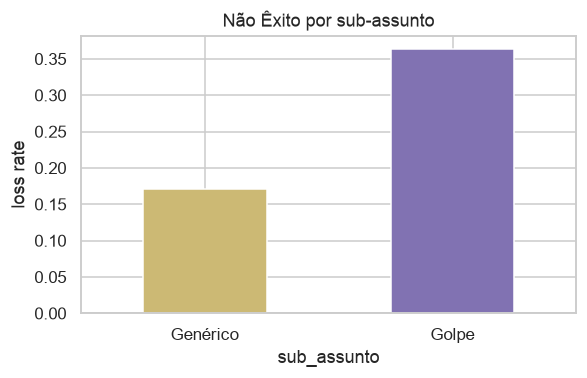

In [19]:
global_exito = df["is_exito"].mean()

sub_target = (
    df.groupby("sub_assunto")
    .agg(
        n=("is_exito", "size"),
        exito_rate=("is_exito", "mean"),
        acordo_n=("is_acordo", "sum"),
        condenacao_sum=("valor_condenacao", "sum"),
        condenacao_mean=("valor_condenacao", "mean"),
    )
    .assign(loss_rate=lambda x: 1 - x["exito_rate"], lift_exito=lambda x: x["exito_rate"] / global_exito)
)
show(sub_target, "Sub-assunto × alvo")

fig, ax = plt.subplots(figsize=(5.5, 3.6))
sub_target["loss_rate"].plot(kind="bar", ax=ax, color=["#CCB974", "#8172B2"])
ax.set_ylabel("loss rate")
ax.set_title("Não Êxito por sub-assunto")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()


UF × alvo (ordenado por loss)


,n,exito_rate,acordo_n,condenacao_mean,condenacao_sum,loss_rate,lift_exito
uf,,,,,,,
AP,2308,0.5160,18,"5,943.9863","13,718,720.2946",0.4840,0.7419
AM,2308,0.5186,21,"6,021.8713","13,898,479.0293",0.4814,0.7456
GO,2308,0.6222,16,"4,079.6666","9,415,870.5041",0.3778,0.8945
RS,2307,0.6229,19,"4,065.4580","9,379,011.5075",0.3771,0.8955
BA,2308,0.6456,14,"4,200.3227","9,694,344.7972",0.3544,0.9282
RJ,2307,0.6524,17,"3,541.4067","8,170,025.3619",0.3476,0.9379
ES,2308,0.6672,9,"3,446.2524","7,953,950.6314",0.3328,0.9593
DF,2308,0.6733,7,"3,325.9770","7,676,354.8503",0.3267,0.9680
SP,2307,0.6909,8,"3,193.0059","7,366,264.6574",0.3091,0.9934


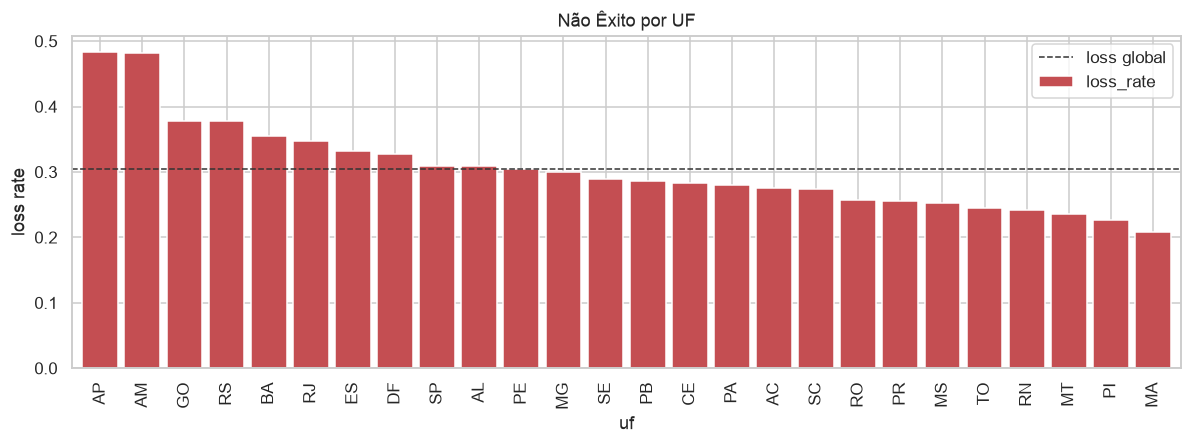

In [20]:
uf_target = (
    df.groupby("uf")
    .agg(
        n=("is_exito", "size"),
        exito_rate=("is_exito", "mean"),
        acordo_n=("is_acordo", "sum"),
        condenacao_mean=("valor_condenacao", "mean"),
        condenacao_sum=("valor_condenacao", "sum"),
    )
    .assign(loss_rate=lambda x: 1 - x["exito_rate"], lift_exito=lambda x: x["exito_rate"] / global_exito)
    .sort_values("loss_rate", ascending=False)
)
show(uf_target, "UF × alvo (ordenado por loss)")

fig, ax = plt.subplots(figsize=(11, 4.2))
uf_target["loss_rate"].plot(kind="bar", ax=ax, color="#C44E52", width=0.85)
ax.axhline((~df["is_exito"]).mean(), color="#333", ls="--", lw=1, label="loss global")
ax.set_ylabel("loss rate")
ax.set_title("Não Êxito por UF")
ax.legend()
plt.tight_layout()
plt.show()


Cada flag × êxito (presente vs ausente)


,documento,estado,n,exito_rate,loss_rate,lift_exito,acordo_n,condenacao_mean
0,Contrato,ausente,17017,0.2469,0.7531,0.3549,207,"7,974.7357"
1,Contrato,presente,42983,0.8732,0.1268,1.2554,73,"1,332.5451"
2,Extrato,ausente,11105,0.1831,0.8169,0.2632,139,"8,639.5400"
3,Extrato,presente,48895,0.8119,0.1881,1.1673,141,"1,984.6768"
4,Comprovante de crédito,ausente,23586,0.5326,0.4674,0.7657,151,"4,940.9012"
5,Comprovante de crédito,presente,36414,0.8011,0.1989,1.1517,129,"2,099.3784"
6,Dossiê,ausente,18014,0.6957,0.3043,1.0003,81,"3,216.6727"
7,Dossiê,presente,41986,0.6955,0.3045,0.9999,199,"3,216.2559"
8,Demonstrativo,ausente,13785,0.6056,0.3944,0.8707,75,"4,187.5505"
9,Demonstrativo,presente,46215,0.7224,0.2776,1.0386,205,"2,926.7008"


Δ êxito (presente − ausente), pontos percentuais


estado,ausente,presente,delta_pp
documento,,,
Extrato,0.1831,0.8119,62.8873
Contrato,0.2469,0.8732,62.6312
Comprovante de crédito,0.5326,0.8011,26.8489
Demonstrativo,0.6056,0.7224,11.6799
Dossiê,0.6957,0.6955,-0.0267
Laudo referenciado,0.6971,0.6952,-0.1928


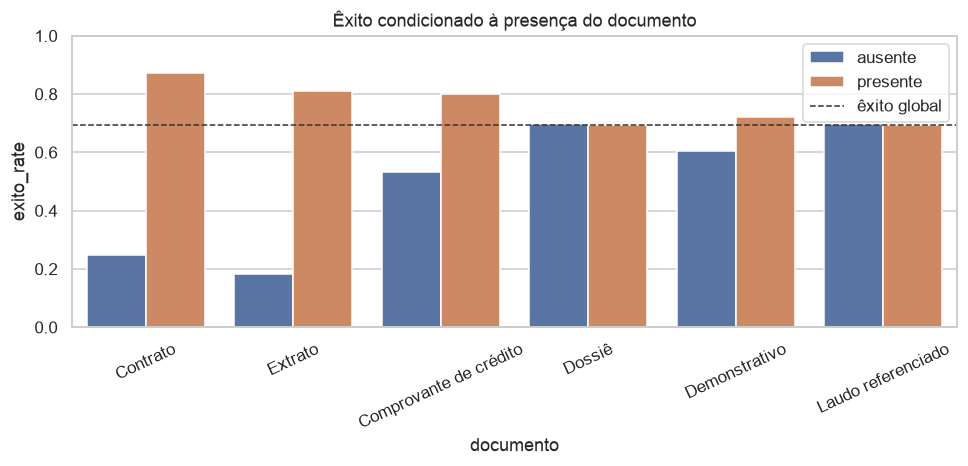

In [21]:
flag_rows = []
for col in DOC_COLS:
    for present, label in [(0, "ausente"), (1, "presente")]:
        mask = df[col].eq(present)
        rate = df.loc[mask, "is_exito"].mean()
        flag_rows.append(
            {
                "documento": DOC_LABELS[col],
                "estado": label,
                "n": int(mask.sum()),
                "exito_rate": rate,
                "loss_rate": 1 - rate,
                "lift_exito": rate / global_exito,
                "acordo_n": int(df.loc[mask, "is_acordo"].sum()),
                "condenacao_mean": df.loc[mask, "valor_condenacao"].mean(),
            }
        )
flag_target = pd.DataFrame(flag_rows)
show(flag_target, "Cada flag × êxito (presente vs ausente)")

delta = (
    flag_target.pivot(index="documento", columns="estado", values="exito_rate")
    .assign(delta_pp=lambda x: (x["presente"] - x["ausente"]) * 100)
    .sort_values("delta_pp", ascending=False)
)
show(delta, "Δ êxito (presente − ausente), pontos percentuais")

plot_df = flag_target.copy()
fig, ax = plt.subplots(figsize=(9, 4.4))
sns.barplot(data=plot_df, x="documento", y="exito_rate", hue="estado", ax=ax)
ax.axhline(global_exito, color="#333", ls="--", lw=1, label="êxito global")
ax.set_ylim(0, 1)
ax.set_title("Êxito condicionado à presença do documento")
ax.tick_params(axis="x", rotation=25)
ax.legend()
plt.tight_layout()
plt.show()


Trio crítico (contrato + extrato + comprovante) × alvo


,n,exito_rate,acordo_n,acordo_rate,condenacao_mean,condenacao_sum,valor_causa_median,loss_rate
n_criticos,,,,,,,,
0,3880,0.0142,61,0.0157,"10,493.1981","40,713,608.5715","15,047.7300",0.9858
1,9946,0.1893,117,0.0118,"8,553.6831","85,074,932.6010","15,083.0400",0.8107
2,20176,0.7368,80,0.0040,"2,770.3001","55,893,574.5328","14,974.3750",0.2632
3,25998,0.9589,22,0.0008,434.6775,"11,300,746.3631","14,964.8200",0.0411


Nº total de docs (0–6) × alvo


,n,exito_rate,acordo_n,condenacao_mean
n_docs,,,,
0,57,0.0000,0,"10,575.2131"
1,745,0.0295,9,"10,331.0551"
2,3498,0.1292,49,"9,189.3447"
3,8811,0.3380,89,"7,002.6724"
4,15719,0.6412,82,"3,798.2668"
5,19518,0.8705,39,"1,362.3262"
6,11652,0.9622,12,389.9524


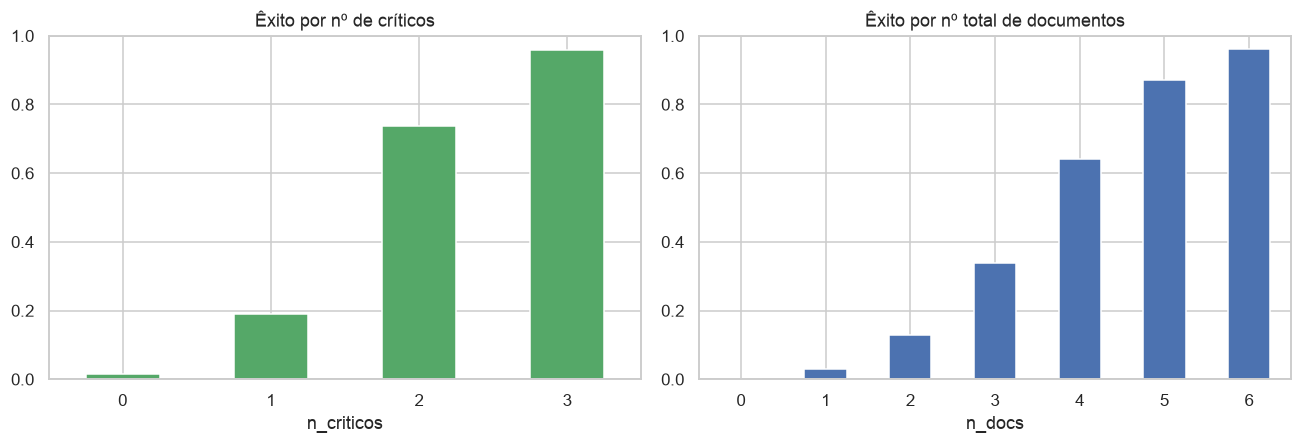

In [22]:
trio = (
    df.groupby("n_criticos")
    .agg(
        n=("is_exito", "size"),
        exito_rate=("is_exito", "mean"),
        acordo_n=("is_acordo", "sum"),
        acordo_rate=("is_acordo", "mean"),
        condenacao_mean=("valor_condenacao", "mean"),
        condenacao_sum=("valor_condenacao", "sum"),
        valor_causa_median=("valor_causa", "median"),
    )
    .assign(loss_rate=lambda x: 1 - x["exito_rate"])
)
show(trio, "Trio crítico (contrato + extrato + comprovante) × alvo")

docs_all = (
    df.groupby("n_docs")
    .agg(
        n=("is_exito", "size"),
        exito_rate=("is_exito", "mean"),
        acordo_n=("is_acordo", "sum"),
        condenacao_mean=("valor_condenacao", "mean"),
    )
)
show(docs_all, "Nº total de docs (0–6) × alvo")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
trio["exito_rate"].plot(kind="bar", ax=axes[0], color="#55A868")
axes[0].set_ylim(0, 1)
axes[0].set_title("Êxito por nº de críticos")
axes[0].set_xlabel("n_criticos")
axes[0].tick_params(axis="x", rotation=0)

docs_all["exito_rate"].plot(kind="bar", ax=axes[1], color="#4C72B0")
axes[1].set_ylim(0, 1)
axes[1].set_title("Êxito por nº total de documentos")
axes[1].set_xlabel("n_docs")
axes[1].tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()


## 8. Interações e matriz de dependência

Cramér's V entre categóricas (incluindo o alvo), loss por UF × tese, êxito
do trio crítico dentro de Golpe vs Genérico, e a razão condenação/causa
por micro-resultado (âncora de pricing).


Cramér's V — categóricas + flags + alvo


,UF,Sub-assunto,Macro,Micro,Contrato,Extrato,Comprovante,Dossiê,Demonstrativo,Laudo,n_criticos
UF,1.0000,0.0210,0.1470,0.0760,0.0940,0.0850,0.0490,0.0230,0.0260,0.0220,0.0640
Sub-assunto,0.0210,1.0000,0.1930,0.2010,0.1190,0.1080,0.0560,0.0050,0.0220,0.0010,0.1370
Macro,0.1470,0.1930,1.0000,1.0000,0.6130,0.5310,0.2850,0.0000,0.1070,0.0020,0.6980
Micro,0.0760,0.2010,1.0000,1.0000,0.6140,0.5310,0.2850,0.0050,0.1080,0.0040,0.4030
Contrato,0.0940,0.1190,0.6130,0.6140,1.0000,0.3180,0.1740,0.0030,0.0680,0.0020,0.7310
Extrato,0.0850,0.1080,0.5310,0.5310,0.3180,1.0000,0.1520,0.0020,0.0560,0.0080,0.7020
Comprovante,0.0490,0.0560,0.2850,0.2850,0.1740,0.1520,1.0000,0.0060,0.0290,0.0030,0.7290
Dossiê,0.0230,0.0050,0.0000,0.0050,0.0030,0.0020,0.0060,1.0000,0.0020,0.0030,0.0100
Demonstrativo,0.0260,0.0220,0.1070,0.1080,0.0680,0.0560,0.0290,0.0020,1.0000,0.0050,0.0750
Laudo,0.0220,0.0010,0.0020,0.0040,0.0020,0.0080,0.0030,0.0030,0.0050,1.0000,0.0080


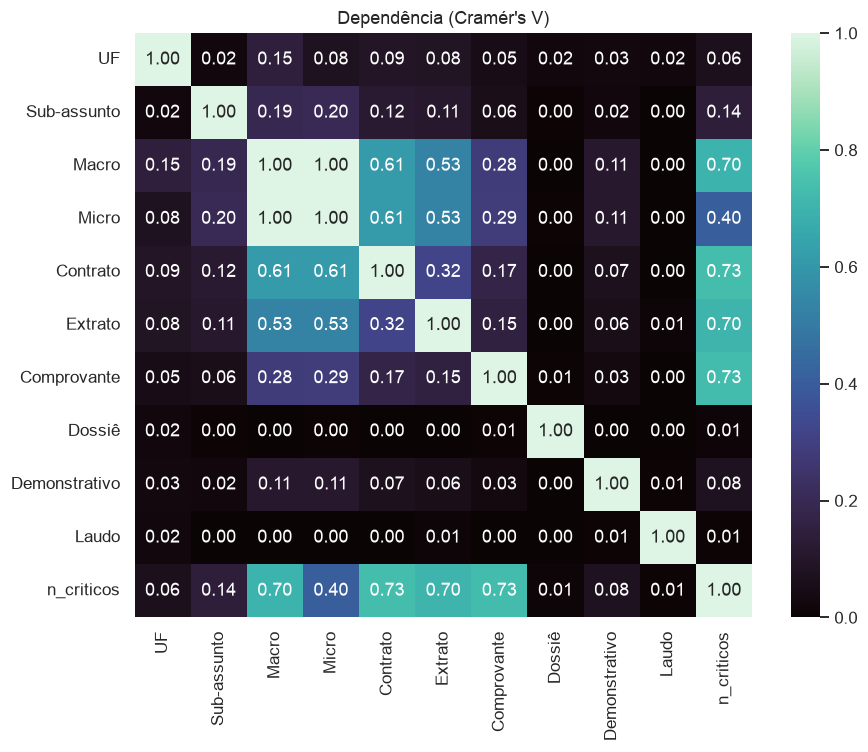

In [23]:
assoc_cols = [
    "uf",
    "sub_assunto",
    "resultado_macro",
    "resultado_micro",
    "has_contrato",
    "has_extrato",
    "has_comprovante",
    "has_dossie",
    "has_demonstrativo",
    "has_laudo",
    "n_criticos",
]
pretty = {
    "uf": "UF",
    "sub_assunto": "Sub-assunto",
    "resultado_macro": "Macro",
    "resultado_micro": "Micro",
    "has_contrato": "Contrato",
    "has_extrato": "Extrato",
    "has_comprovante": "Comprovante",
    "has_dossie": "Dossiê",
    "has_demonstrativo": "Demonstrativo",
    "has_laudo": "Laudo",
    "n_criticos": "n_criticos",
}

cramer_all = cramers_v_matrix(df, assoc_cols)
cramer_all.index = [pretty[c] for c in assoc_cols]
cramer_all.columns = [pretty[c] for c in assoc_cols]
show(cramer_all.round(3), "Cramér's V — categóricas + flags + alvo")

fig, ax = plt.subplots(figsize=(8.5, 7))
sns.heatmap(cramer_all, annot=True, fmt=".2f", cmap="mako", ax=ax, vmin=0, vmax=1)
ax.set_title("Dependência (Cramér's V)")
plt.tight_layout()
plt.show()


Informação mútua normalizada com o alvo macro


,NMI vs resultado_macro
Micro,0.6530
Contrato,0.3033
n_criticos,0.2873
Extrato,0.2424
Comprovante,0.0625
Sub-assunto,0.0325
Demonstrativo,0.0096
UF,0.0054
Laudo,0.0000
Dossiê,0.0000


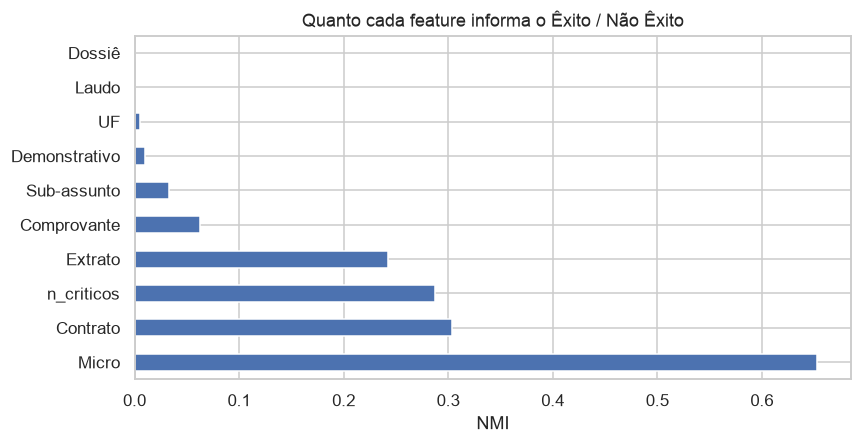

In [24]:
nmi_target = pd.Series(
    {
        pretty[col]: normalized_mutual_info_score(df[col].astype(str), df["resultado_macro"])
        for col in assoc_cols
        if col != "resultado_macro"
    }
).sort_values(ascending=False)
show(nmi_target.rename("NMI vs resultado_macro").to_frame(), "Informação mútua normalizada com o alvo macro")

fig, ax = plt.subplots(figsize=(8, 4.2))
nmi_target.plot(kind="barh", ax=ax, color="#4C72B0")
ax.set_xlabel("NMI")
ax.set_title("Quanto cada feature informa o Êxito / Não Êxito")
plt.tight_layout()
plt.show()


Loss rate UF × sub-assunto


sub_assunto,Genérico,Golpe
uf,,
AC,0.1533,0.3321
AL,0.1657,0.3728
AM,0.3411,0.5403
AP,0.3150,0.5563
BA,0.2293,0.4131
CE,0.1613,0.3421
DF,0.2034,0.3812
ES,0.2089,0.3937
GO,0.2461,0.4360


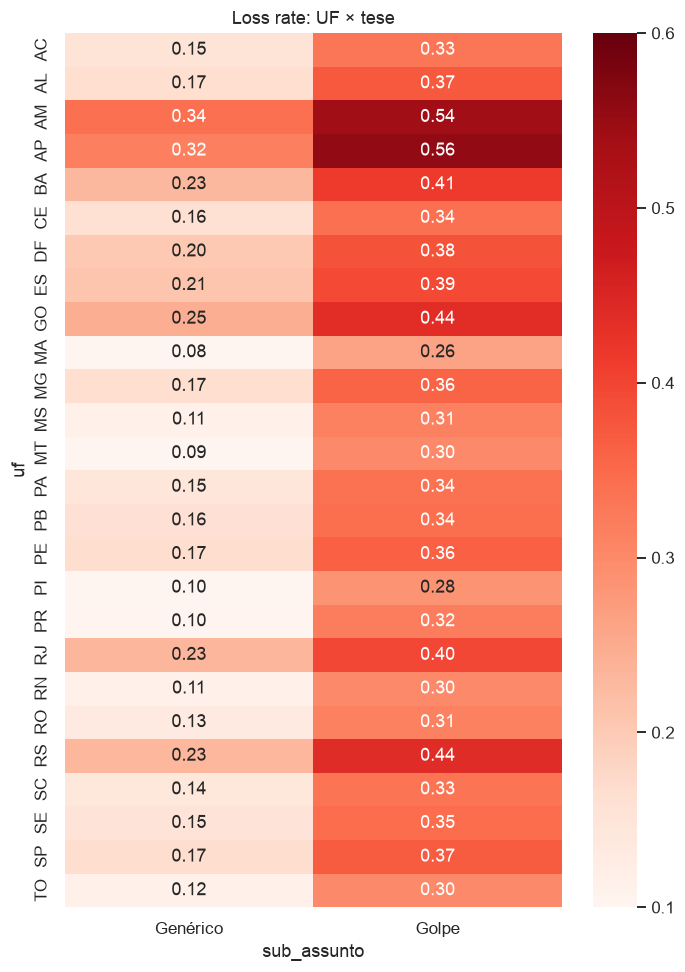

In [25]:
loss_uf_sub = (
    df.assign(loss=~df["is_exito"])
    .pivot_table(index="uf", columns="sub_assunto", values="loss", aggfunc="mean")
    .sort_index()
)
show(loss_uf_sub, "Loss rate UF × sub-assunto")

fig, ax = plt.subplots(figsize=(6.5, 9))
sns.heatmap(loss_uf_sub, annot=True, fmt=".2f", cmap="Reds", ax=ax, vmin=0.1, vmax=0.6)
ax.set_title("Loss rate: UF × tese")
plt.tight_layout()
plt.show()


Trio crítico × sub-assunto


,n_criticos,sub_assunto,n,exito_rate,acordo_n,condenacao_mean
0,0,Genérico,664,0.0286,16,"9,472.6773"
1,0,Golpe,3216,0.0112,45,"10,703.9026"
2,1,Genérico,2076,0.3266,22,"6,588.8394"
3,1,Golpe,7870,0.1531,95,"9,071.9825"
4,2,Genérico,6281,0.8583,13,"1,352.6546"
5,2,Golpe,13895,0.6818,67,"3,411.1228"
6,3,Genérico,9351,0.9787,4,213.3081
7,3,Golpe,16647,0.9478,18,559.0258


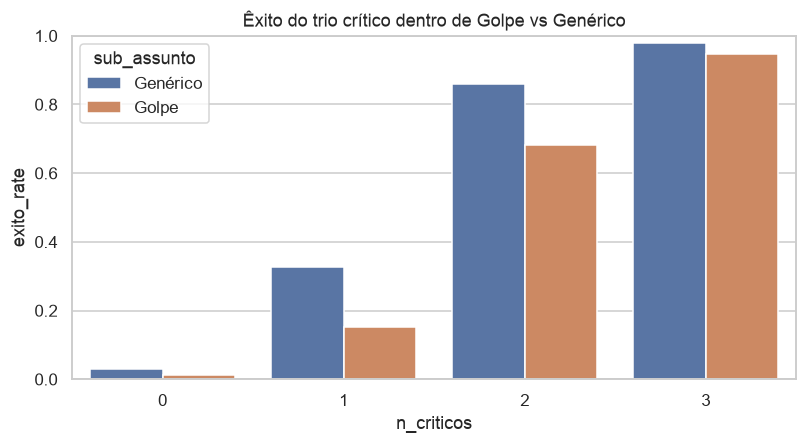

Leitura esperada: o trio move o êxito nos dois teses; Golpe fica abaixo de Genérico em cada degrau.


In [26]:
trio_sub = (
    df.groupby(["n_criticos", "sub_assunto"])
    .agg(
        n=("is_exito", "size"),
        exito_rate=("is_exito", "mean"),
        acordo_n=("is_acordo", "sum"),
        condenacao_mean=("valor_condenacao", "mean"),
    )
    .reset_index()
)
show(trio_sub, "Trio crítico × sub-assunto")

fig, ax = plt.subplots(figsize=(7.5, 4.2))
sns.barplot(data=trio_sub, x="n_criticos", y="exito_rate", hue="sub_assunto", ax=ax)
ax.set_ylim(0, 1)
ax.set_title("Êxito do trio crítico dentro de Golpe vs Genérico")
plt.tight_layout()
plt.show()

print("Leitura esperada: o trio move o êxito nos dois teses; Golpe fica abaixo de Genérico em cada degrau.")


vd/vc (condenação ÷ causa) por resultado micro


,n,vd_vc_p25,vd_vc_median,vd_vc_p75,vd_vc_p90,vd_vc_mean,condenacao_median,causa_median
resultado_micro,,,,,,,,
Improcedência,27935,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,"14,974.5100"
Extinção,13798,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,"14,978.6200"
Acordo,280,0.2500,0.2900,0.3500,0.3900,0.2978,"4,361.9049","15,481.1750"
Parcial procedência,12248,0.4900,0.6300,0.7500,0.8300,0.6224,"8,827.7545","14,985.3100"
Procedência,5739,0.8500,0.9000,0.9500,0.9800,0.8995,"13,472.0289","15,108.1800"


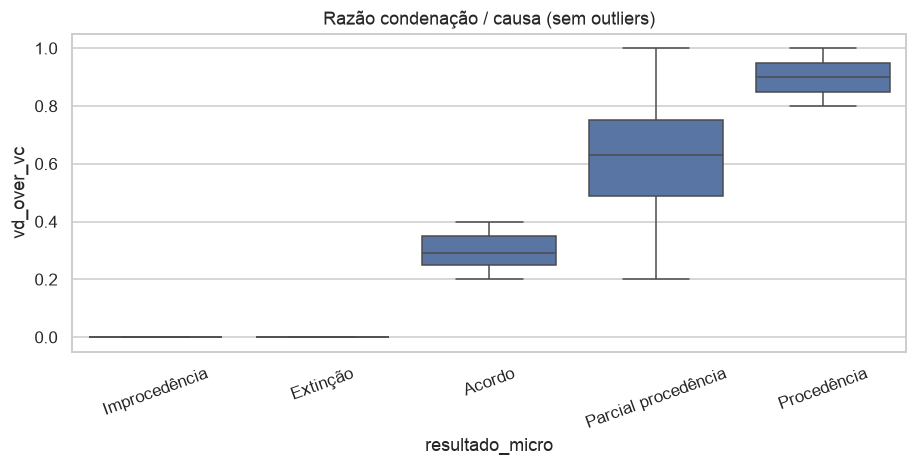

Acordo histórico vd/vc: n=280  P25=0.250  mediana=0.290  P90=0.390


In [27]:
ratio = (
    df.groupby("resultado_micro")
    .agg(
        n=("vd_over_vc", "size"),
        vd_vc_p25=("vd_over_vc", lambda s: s.quantile(0.25)),
        vd_vc_median=("vd_over_vc", "median"),
        vd_vc_p75=("vd_over_vc", lambda s: s.quantile(0.75)),
        vd_vc_p90=("vd_over_vc", lambda s: s.quantile(0.90)),
        vd_vc_mean=("vd_over_vc", "mean"),
        condenacao_median=("valor_condenacao", "median"),
        causa_median=("valor_causa", "median"),
    )
    .reindex(["Improcedência", "Extinção", "Acordo", "Parcial procedência", "Procedência"])
)
show(ratio, "vd/vc (condenação ÷ causa) por resultado micro")

fig, ax = plt.subplots(figsize=(8.5, 4.4))
order = ["Improcedência", "Extinção", "Acordo", "Parcial procedência", "Procedência"]
sns.boxplot(
    data=df,
    x="resultado_micro",
    y="vd_over_vc",
    order=order,
    ax=ax,
    showfliers=False,
)
ax.set_title("Razão condenação / causa (sem outliers)")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

acordo = df.loc[df["is_acordo"], "vd_over_vc"]
print(
    f"Acordo histórico vd/vc: n={int(df['is_acordo'].sum()):,}  "
    f"P25={acordo.quantile(0.25):.3f}  mediana={acordo.median():.3f}  "
    f"P90={acordo.quantile(0.90):.3f}"
)


Quintis de valor da causa × alvo


,n,valor_causa_median,exito_rate,acordo_n,condenacao_mean
causa_bin,,,,,
Q1,12000,"8,551.0200",0.6938,51,"1,741.6497"
Q2,12000,"12,283.7400",0.6992,52,"2,601.5903"
Q3,12000,"14,992.9300",0.6980,59,"3,157.8034"
Q4,12000,"17,673.8950",0.6945,62,"3,812.3991"
Q5,12000,"21,393.1650",0.6923,56,"4,768.4626"


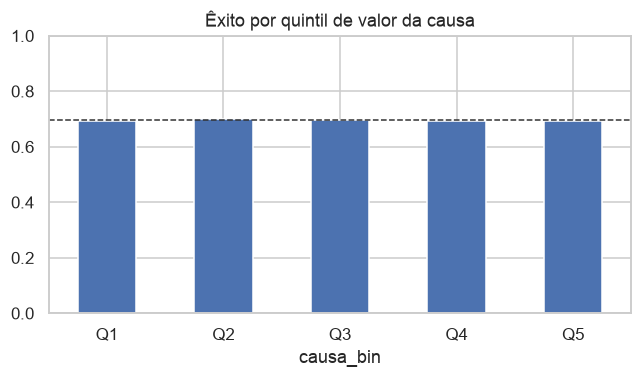

In [28]:
# Ticket vs desfecho: o valor da causa sozinho move o êxito?
df["causa_bin"] = pd.qcut(df["valor_causa"], q=5, labels=["Q1", "Q2", "Q3", "Q4", "Q5"])
causa_target = (
    df.groupby("causa_bin", observed=False)
    .agg(
        n=("is_exito", "size"),
        valor_causa_median=("valor_causa", "median"),
        exito_rate=("is_exito", "mean"),
        acordo_n=("is_acordo", "sum"),
        condenacao_mean=("valor_condenacao", "mean"),
    )
)
show(causa_target, "Quintis de valor da causa × alvo")

fig, ax = plt.subplots(figsize=(6, 3.6))
causa_target["exito_rate"].plot(kind="bar", ax=ax, color="#4C72B0")
ax.axhline(global_exito, color="#333", ls="--", lw=1)
ax.set_ylim(0, 1)
ax.set_title("Êxito por quintil de valor da causa")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()


## 9. Conclusões

Números abaixo são recalculados nesta execução (não copiados do markdown de análise).


In [29]:
def pct(x: float) -> str:
    return f"{x:.1%}"


def brl(x: float) -> str:
    return f"R$ {x:,.2f}"


n = len(df)
exito = df["is_exito"].mean()
loss = 1 - exito
n_acordo = int(df["is_acordo"].sum())
condenacao_total = df.loc[~df["is_exito"], "valor_condenacao"].sum()
acordo_ratio = df.loc[df["is_acordo"], "vd_over_vc"]
delta_docs = delta["delta_pp"].sort_values(ascending=False)
worst_uf = uf_target["loss_rate"].idxmax()
best_uf = uf_target["loss_rate"].idxmin()

print("=== Números-chave desta execução ===")
print(f"N = {n:,}")
print(f"Êxito {pct(exito)} · Não Êxito {pct(loss)} · Acordo {n_acordo:,} ({n_acordo / n:.3%})")
print(f"Condenação total: {brl(condenacao_total)}")
print(f"Assunto constante: {df['assunto'].nunique() == 1} ({df['assunto'].iloc[0]})")
print(f"UFs: {df['uf'].nunique()} · min {int(uf_counts['n'].min())} · max {int(uf_counts['n'].max())}")
print(f"UF pior loss: {worst_uf} {pct(uf_target.loc[worst_uf, 'loss_rate'])} · melhor: {best_uf} {pct(uf_target.loc[best_uf, 'loss_rate'])}")
print("Loss por sub-assunto:")
print(sub_target[["n", "loss_rate"]].to_string())
print("Êxito por n_criticos:")
print(trio[["n", "exito_rate", "acordo_n", "condenacao_mean"]].to_string())
print("Δ êxito presente−ausente (pp):")
print(delta_docs.to_string())
print(
    f"Acordo vd/vc P25={acordo_ratio.quantile(0.25):.3f} "
    f"mediana={acordo_ratio.median():.3f} P90={acordo_ratio.quantile(0.90):.3f}"
)
print("Cramér's V vs Macro (ordenado):")
print(cramer_all["Macro"].sort_values(ascending=False).to_string())
print(f"Overlap com Casos 01/02: {int(df['process_number'].isin(EXAMPLE_CASES).sum())}")
print(f"Join 1:1 e condenação=0 ⇔ êxito: {bool(cond_when_exito.eq(0).all() and (cond_when_loss > 0).all())}")


=== Números-chave desta execução ===
N = 60,000
Êxito 69.6% · Não Êxito 30.4% · Acordo 280 (0.467%)
Condenação total: R$ 192,982,862.07
Assunto constante: True (Não reconhece operação)
UFs: 26 · min 2307 · max 2308
UF pior loss: AP 48.4% · melhor: MA 20.8%
Loss por sub-assunto:
                 n  loss_rate
sub_assunto                  
Genérico     18372     0.1705
Golpe        41628     0.3636
Êxito por n_criticos:
                n  exito_rate  acordo_n  condenacao_mean
n_criticos                                              
0            3880      0.0142        61      10,493.1981
1            9946      0.1893       117       8,553.6831
2           20176      0.7368        80       2,770.3001
3           25998      0.9589        22         434.6775
Δ êxito presente−ausente (pp):
documento
Extrato                  62.8873
Contrato                 62.6312
Comprovante de crédito   26.8489
Demonstrativo            11.6799
Dossiê                   -0.0267
Laudo referenciado       -0.192

### O que as features são (e o que não são)

Números desta execução (N = 60.000).

1. **O dataset é tabular sintético/tratado, não texto de sentença.** Não há PDF dos 60k.
   Os flags dizem “o arquivo chegou?”, não “o arquivo presta?”. CONFORME / liveness /
   conta CEF vs conta da autora **não existem** nesta planilha. Os Casos 01/02
   **não estão** na base (overlap = 0).

2. **Opções com sinal:** `uf` (26 UFs, 2.307–2.308 cada; **RR ausente**),
   `sub_assunto` ({Golpe 69,4%, Genérico 30,6%}), `resultado_micro` (Improcedência,
   Extinção, Parcial procedência, Procedência, Acordo), `valor_causa` (~R$ 1k–31k),
   6 booleanos de subsídio. `assunto` é 100% `Não reconhece operação` — drop.

3. **Dependências estruturais (regras, 60k/60k):**
   - join 1:1 perfeito entre as duas abas;
   - `Êxito` (69,6%) = Improcedência ∪ Extinção, condenação sempre 0;
   - `Não Êxito` (30,4%) = Procedência ∪ Parcial ∪ **Acordo**, condenação sempre > 0;
   - Cramér's V(macro, micro) = 1,0. Não usar macro nem o zero da condenação como
     feature se o alvo for o próprio desfecho.

4. **Dependências entre documentos:** os 6 flags **não** formam um bloco único
   (Pearson / Cramér's V entre pares baixos). Não é “tudo ou nada”.
   Δ êxito presente − ausente: Extrato +62,9 pp, Contrato +62,6 pp,
   Comprovante +26,8 pp, Demonstrativo +11,7 pp, Dossiê −0,03 pp, Laudo −0,19 pp.
   Dossiê e laudo, como presença, são ruído. O conteúdo (que a planilha não tem)
   é o que separa o Caso 01 do Caso 02.

5. **Trio crítico é a feature dominante.** Êxito: 1,4% (0 críticos, n=3.880) →
   18,9% (1) → 73,7% (2) → 95,9% (3, n=25.998). Cramér's V vs macro:
   `n_criticos` 0,70 · Contrato 0,61 · Extrato 0,53 · Comprovante 0,29 ·
   Sub-assunto 0,19 · UF 0,15 · Demonstrativo 0,11 · Laudo/Dossiê ≈ 0.

6. **Golpe é bem mais caro que Genérico:** loss 36,4% vs 17,0%. A interação
   trio × tese mostra o mesmo degrau nos dois grupos, com Golpe abaixo em cada
   degrau — a tese não some quando a prova chega.

7. **UF é feature de risco, mas a amostragem é artificial.** Pior: AP 48,4% e
   AM 48,1%. Melhor: MA 20,8%. SP tem o mesmo n que AP. Serve para calibrar
   risco relativo, não volume nacional. RR não aparece.

8. **Não classificar acordo vs defesa direto.** Acordo = 280 / 60.000 (0,467%).
   O banco já paga em 30,4% dos casos (R$ 192,98 mi). Acordo é só a fatia
   explícita disso. Alvo natural: P(Não Êxito) ou P(êxito | prova).

9. **Âncora de pricing:** acordos históricos vd/vc P25=0,25 · mediana=0,29 ·
   P90=0,39. Valor da causa sozinho (quintis) move pouco o êxito — o ticket
   precifica a banda, não a decisão.

10. **Demo ≠ massa.** Política Caso 01 = defesa / Caso 02 = acordo tem de ler o
    PDF. Um classificador só nos 0/1 erra o Caso 02 se “tem BACEN” virar voto
    de defesa.

### Uso imediato

- Features para regra / modelo cinza: `n_criticos` (ou os 3 flags), `sub_assunto`,
  `uf`; `valor_causa` só para a banda. Dossiê e laudo como presença: não entrar.
  Demonstrativo: sinal fraco, opcional.
- Explicação para o advogado: citar o degrau do trio e a tese; não citar “tem
  dossiê” como se fosse prova de autoria.
- Próximo passo (fora deste notebook): policy + simulação de economia, não
  classificador de acordo.
